# Does precinct order affect the unmixing?

Here we check whether the *order of the precinct columns* in `Y` plays a part in the
observed regionalism in archetypes. In exact arithmetic the whole pipeline
(est_noise → HySime → MVSA → SUNSAL) is permutation-equivariant in the precinct axis:
shuffling the columns of `Y` should permute the abundances identically and leave the
endmembers untouched. Any difference we see therefore comes from

1. floating-point non-associativity (summation order in matrix products) propagating
   through the SVDs and MVSA's iterative optimisation, and
2. data-dependent tie-breaks (e.g. argmax picks in VCA).

The only *explicit* randomness in the pipeline is VCA's random projection draws inside
MVSA's initialisation, driven by the global NumPy seed. To isolate ordering from
initialisation we run three arms against a common **reference run** (canonical order,
seed = config seed):

- **Arm A — determinism check (the floor):** canonical order, same seed, run
  `n_trials` times. Every run should be bitwise identical to the reference
  (similarity ≡ 1); confirms the baseline is deterministic and anchors the
  comparison plots.
- **Arm B — order sensitivity (the question):** shuffled precinct order
  (`randomize_precinct_order=True` in preprocessing, a per-trial shuffle seed),
  **fixed** pipeline seed. Candidate/column order (senatorial, ranked by national
  total) is untouched by the shuffle. Abundances are mapped back to the reference
  precinct order before comparison.
- **Arm C — seed sensitivity (the yardstick):** canonical order, **varying** pipeline
  seed. Puts Arm B's variability in context: if B ≪ C, ordering is a non-issue
  relative to initialisation.

The whole design is swept over **archetype counts `p = 2 … 6`**. The two anchors:
`p = 6` is the config value, and `p = 4` is where notebook 08's sweep puts the
minimum pairwise distance between archetypes across metrics — i.e. the largest `p`
whose archetypes stay mutually distinct. An earlier two-point run (`p ∈ {6, 4}`)
found sensitivity at 6 and near-none at 4; the sweep maps out where the instability
sets in.

Matching across runs is evaluated under a **suite of rank metrics** (Spearman ρ,
rank-biased overlap, weighted Kendall τ, top-12 Jaccard) plus cosine — see the
matching section for why.

In [1]:
import pickle
import sys
from pathlib import Path
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm

from scipy.stats import pearsonr

from src.config import load_config
from src.data import load_complete
from src.data.preprocessing import preprocess_from_config
from src.unmixing import est_noise, hysime, mvsa, sunsal_mod
from src.unmixing.matching import match_to_reference, similarity_matrix

sns.set_style('whitegrid')
config = load_config()

In [2]:
def run_pipeline(Y_in, p, seed, verbose=False):
    """Run the full unmixing pipeline on one vote matrix.

    est_noise -> HySime (signal-subspace estimate kf) -> MVSA (endmembers)
    -> SUNSAL (abundances), with MVSA/SUNSAL settings from the config.

    Parameters
    ----------
    Y_in : ndarray, shape (L, N)
        Vote matrix, candidates x precincts.
    p : int or None
        Number of archetypes; None uses the HySime estimate kf.
    seed : int
        Global NumPy seed set before the run; controls VCA's random
        projections inside MVSA's initialisation (the pipeline's only
        explicit randomness).
    verbose : bool, default False
        Print kf, the archetype count used, and the reconstruction RMSE.

    Returns
    -------
    result : dict
        ``endm`` (L, p) endmember loadings, ``abundances`` (p, N),
        ``kf`` HySime subspace estimate, ``n_arch`` archetype count used,
        ``rmse`` reconstruction root-mean-square error.
    """
    np.random.seed(seed)
    w_hat, Rw_hat = est_noise(Y_in, noise_type='additive', verbose=False)
    kf, Ek, E, delta_p = hysime(Y_in, w_hat, Rw_hat, verbose=False)
    n_arch = p or kf
    endm, Sest, Up, my, sing_values = mvsa(
        Y_in, p=n_arch,
        MM_iters=config['unmixing'].getint('mvsa_mm_iters'),
        spherize='yes', verbose=0)
    abundances, res_p, res_d = sunsal_mod(
        endm, Y_in, positivity='yes', addone='yes',
        AL_iters=config['unmixing'].getint('sunsal_al_iters'),
        lambda_=0.0, tol=config['unmixing'].getfloat('sunsal_tol'), verbose='no')
    Y_rec = endm @ abundances
    rmse = float(np.sqrt(np.mean((Y_in - Y_rec) ** 2)))
    if verbose:
        print(f'kf={kf}, n_arch={n_arch}, RMSE={rmse:.6f}')
    return {'endm': endm, 'abundances': abundances, 'kf': int(kf),
            'n_arch': int(n_arch), 'rmse': rmse}

In [3]:
SEED = config['unmixing'].getint('seed')   # pipeline (VCA/MVSA init) seed
PERM_SEED = 1000                           # separate stream for the precinct shuffles
P = config['unmixing'].getint('n_archetypes') or None
PS = [2, 3, 4, 5, 6]   # sweep; anchors: config value (6) and nb08's min-pairwise-distance choice (4)
n_trials = 10

df = load_complete(config)

# Canonical preprocessing: reference precinct order shared by all runs
pre_ref = preprocess_from_config(df, config)
Y_ref = pre_ref.Y
L, N = Y_ref.shape
candidate_labels = pre_ref.candidate_labels
ref_ids = pd.Index(pre_ref.params['precinct_ids'])

candidates: 66 -> 66 (25th pct >= 1.0)
precincts:  92,488 -> 92,487 (total votes >= 1.0)
Y: 66 candidates x 92,487 precincts (valid_ballots normalization)


In [4]:
def run_experiment(p_run):
    """Run the full order-sensitivity design at one archetype count.

    Reference run (canonical order, config seed), Arm A (identical reruns,
    determinism floor), Arm B (shuffled precinct order, fixed seed), and
    Arm C (canonical order, varying seed).

    Parameters
    ----------
    p_run : int
        Number of archetypes passed to every pipeline run.

    Returns
    -------
    experiment : dict
        ``ref`` — reference `run_pipeline` result; ``A``, ``B`` and ``C`` —
        lists of `n_trials` results. Arm B abundances are already mapped back
        to the reference precinct order, so all results are directly
        comparable.
    """
    ref = run_pipeline(Y_ref, p=p_run, seed=SEED)

    results_A = [run_pipeline(Y_ref, p=p_run, seed=SEED)             # identical reruns
                 for _ in tqdm.tqdm(range(n_trials), desc=f'p={p_run} Arm A (rerun)')]

    results_B = []
    for trial in tqdm.tqdm(range(n_trials), desc=f'p={p_run} Arm B (shuffled order)'):
        np.random.seed(PERM_SEED + trial)        # drives only the precinct shuffle
        pre = preprocess_from_config(df, config, randomize_precinct_order=True, verbose=False)
        assert pre.ranked_columns == pre_ref.ranked_columns   # candidate order untouched

        res = run_pipeline(pre.Y, p=p_run, seed=SEED)         # same pipeline seed as reference

        # abundances back into reference precinct order: trial column j is precinct
        # pre.params['precinct_ids'][j], which sits at position pos[j] in the reference
        pos = ref_ids.get_indexer(pre.params['precinct_ids'])
        assert (pos >= 0).all() and len(np.unique(pos)) == N
        A = np.empty_like(res['abundances'])
        A[:, pos] = res['abundances']
        res['abundances'] = A
        results_B.append(res)

    results_C = [run_pipeline(Y_ref, p=p_run, seed=SEED + 1 + t)   # offset: SEED is the reference
                 for t in tqdm.tqdm(range(n_trials), desc=f'p={p_run} Arm C (varying seed)')]

    return {'ref': ref, 'A': results_A, 'B': results_B, 'C': results_C}


# On-disk cache (gitignored): ~0.5 GB total across p=2..6, dominated by the
# (p x 92k) abundance matrices. Delete a file (or the folder) to force recompute;
# the filename pins everything the result depends on.
CACHE_DIR = Path('../data/notebook_experiments/09_precinct_order')
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def cached_experiment(p_run):
    f = CACHE_DIR / f'exp_p{p_run}_seed{SEED}_permseed{PERM_SEED}_trials{n_trials}.pkl'
    if f.exists():
        with open(f, 'rb') as fh:
            return pickle.load(fh)
    e = run_experiment(p_run)
    with open(f, 'wb') as fh:
        pickle.dump(e, fh, protocol=pickle.HIGHEST_PROTOCOL)
    return e


exp = {p_run: cached_experiment(p_run) for p_run in PS}

for p_run, e in exp.items():
    rmses = [e['ref']['rmse']] + [r['rmse'] for arm in 'ABC' for r in e[arm]]
    print(f"p={p_run}: ref RMSE={e['ref']['rmse']:.6f}, "
          f"RMSE range over all {1 + 3 * n_trials} runs: [{min(rmses):.6f}, {max(rmses):.6f}]")

p=2: ref RMSE=0.057802, RMSE range over all 31 runs: [0.057802, 0.057802]
p=3: ref RMSE=0.047529, RMSE range over all 31 runs: [0.047529, 0.047529]
p=4: ref RMSE=0.038639, RMSE range over all 31 runs: [0.038639, 0.038639]
p=5: ref RMSE=0.035741, RMSE range over all 31 runs: [0.035741, 0.035741]
p=6: ref RMSE=0.033695, RMSE range over all 31 runs: [0.033695, 0.033696]


## Arm A — determinism check

Same data, same order, same seed: every Arm A trial must be bitwise identical to the
reference, otherwise there is uncontrolled randomness and the arms below are confounded.
(Arm A also rides along through the matching below as the similarity-≡-1 floor of the
comparison plots.)

In [5]:
for p_run in PS:
    e = exp[p_run]
    endm_ok = all(np.array_equal(e['ref']['endm'], r['endm']) for r in e['A'])
    abund_ok = all(np.array_equal(e['ref']['abundances'], r['abundances']) for r in e['A'])
    max_d_endm = max(np.abs(e['ref']['endm'] - r['endm']).max() for r in e['A'])
    max_d_ab = max(np.abs(e['ref']['abundances'] - r['abundances']).max() for r in e['A'])
    print(f'p={p_run}: all {n_trials} Arm A trials bitwise identical to reference — '
          f'endm: {endm_ok}, abund: {abund_ok} '
          f'(max |Δ endm|={max_d_endm:.1e}, max |Δ abund|={max_d_ab:.1e})')

p=2: all 10 Arm A trials bitwise identical to reference — endm: True, abund: True (max |Δ endm|=0.0e+00, max |Δ abund|=0.0e+00)
p=3: all 10 Arm A trials bitwise identical to reference — endm: True, abund: True (max |Δ endm|=0.0e+00, max |Δ abund|=0.0e+00)
p=4: all 10 Arm A trials bitwise identical to reference — endm: True, abund: True (max |Δ endm|=0.0e+00, max |Δ abund|=0.0e+00)
p=5: all 10 Arm A trials bitwise identical to reference — endm: True, abund: True (max |Δ endm|=0.0e+00, max |Δ abund|=0.0e+00)
p=6: all 10 Arm A trials bitwise identical to reference — endm: True, abund: True (max |Δ endm|=0.0e+00, max |Δ abund|=0.0e+00)


## Reference archetypes at each p

The canonical-order, config-seed solution each arm is compared against.

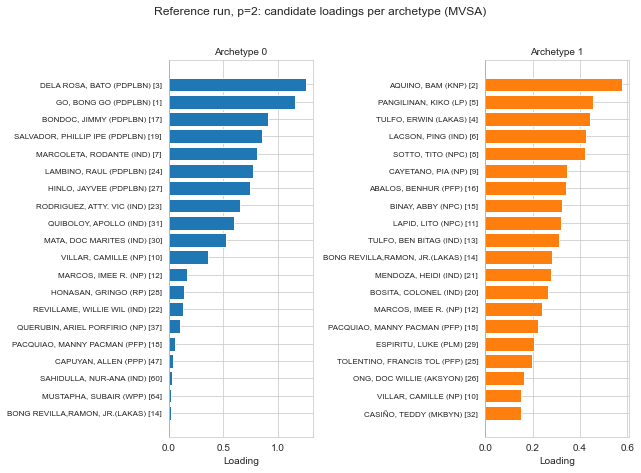

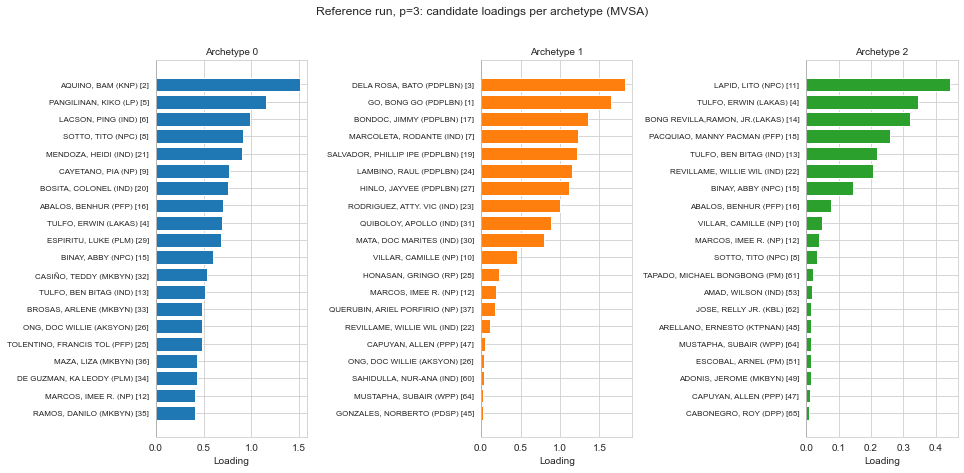

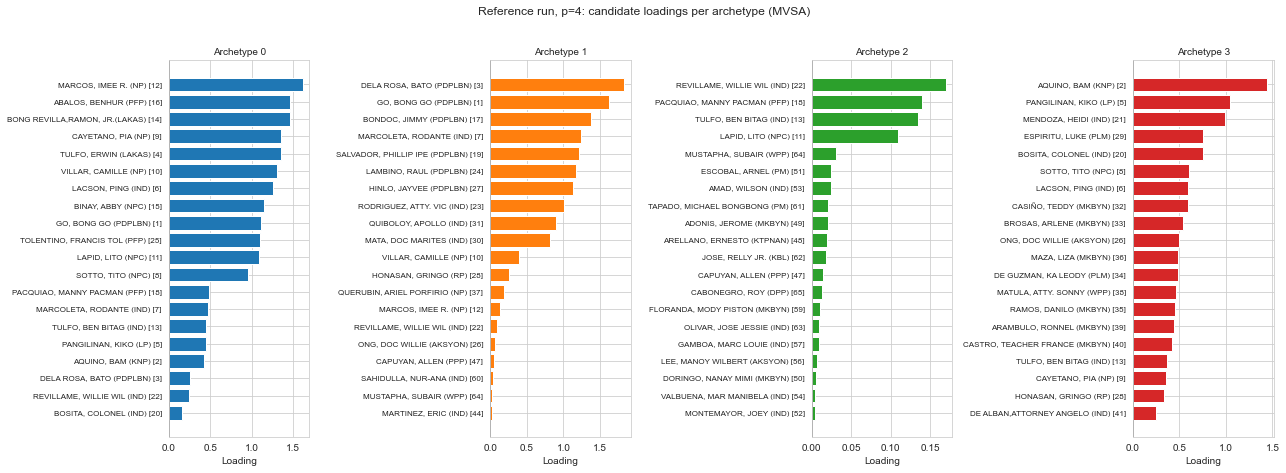

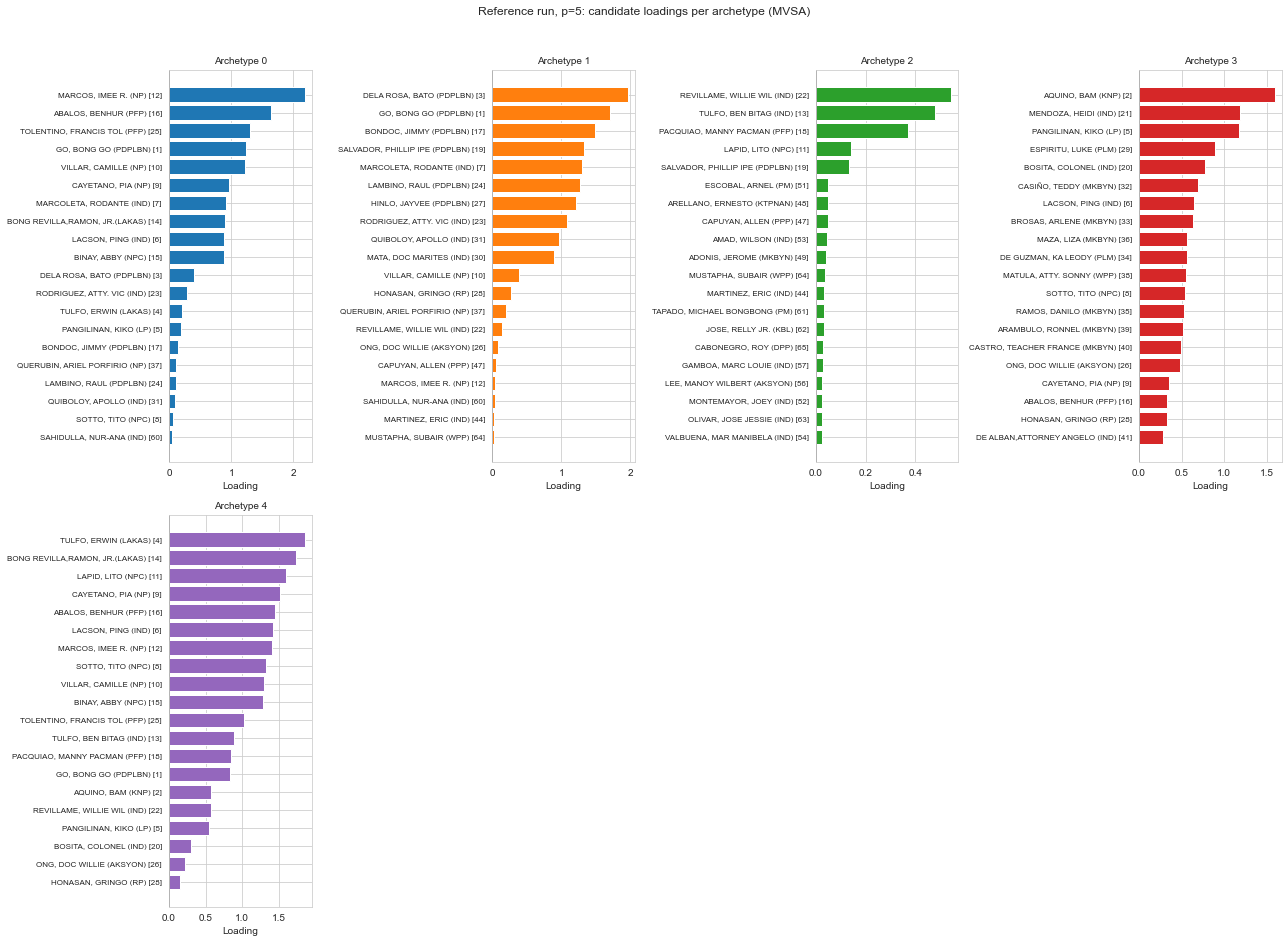

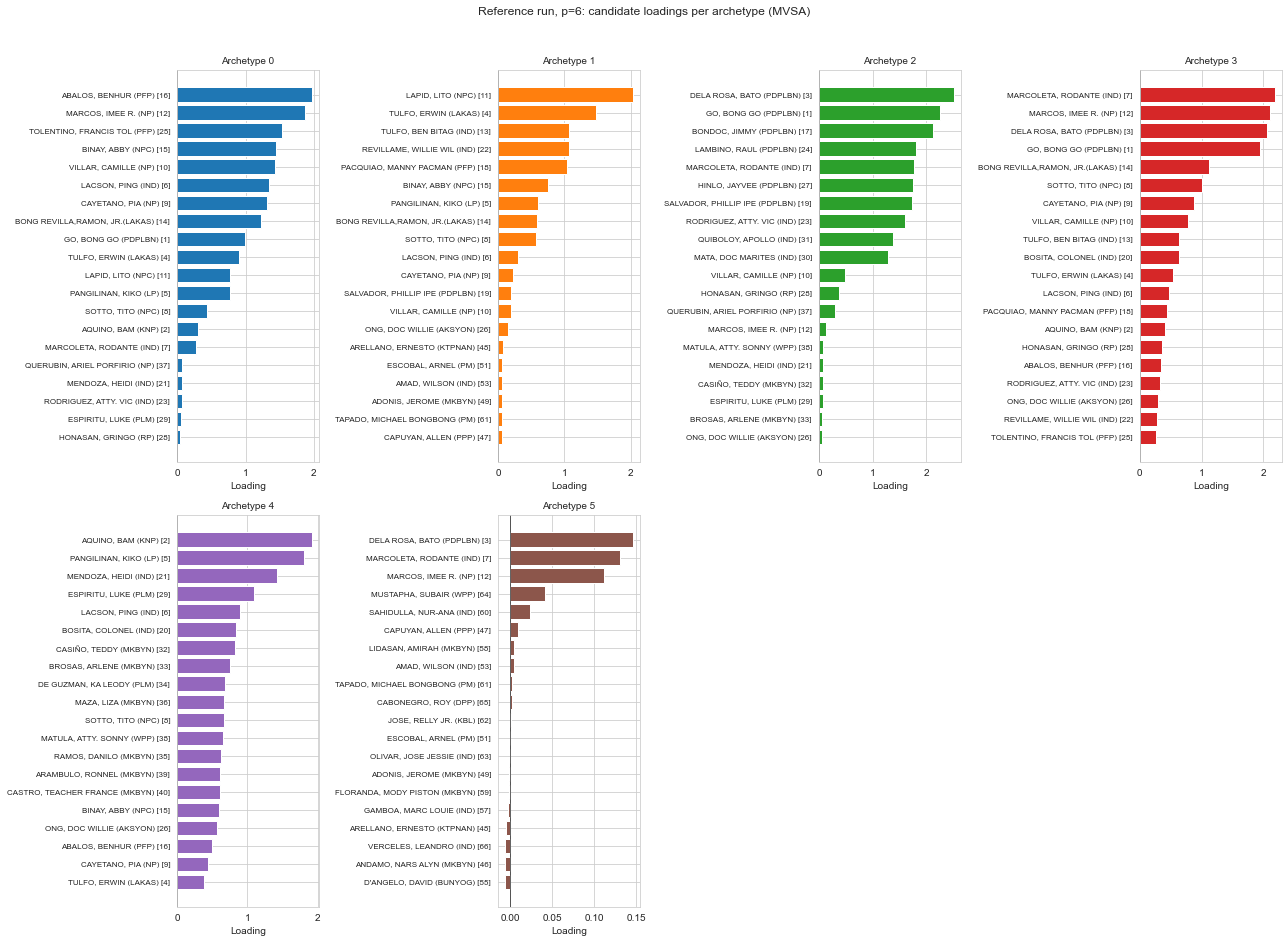

In [6]:
from src.figures import plot_archetypes_loadings_grid

for p_run in PS:
    plot_archetypes_loadings_grid(
        exp[p_run]['ref']['endm'], candidate_labels, top_n=20,
        suptitle=f'Reference run, p={p_run}: candidate loadings per archetype (MVSA)')

## Matching archetypes across trials

MVSA returns archetypes in arbitrary column order, so each trial must be aligned to the
reference before comparing. We use **Hungarian assignment** (`linear_sum_assignment`) on a
column-similarity matrix, evaluated under a suite of metrics (same definitions as
notebook 08, now in `src.unmixing.matching`):

- **Spearman ρ** — rank correlation over all 66 candidates, every rank weighted equally.
  Its weakness here: most of the ranking is the long tail of no-hope candidates, so
    - agreement in the tail can mask disagreement among the candidates that actually define
  the archetype
    - disagreement in the tail can overestimate archetype discrepancy among top candidates
- **Rank-biased overlap (RBO**, extrapolated, `pval = 0.9`**)** — top-weighted set
  overlap at increasing depths; agreement among the top-ranked candidates counts most.
- **Weighted Kendall τ** (scipy, hyperbolic weights) — like Kendall τ but exchanges near
  the top cost more; a top-weighted take on the full ordering.
- **Top-12 Jaccard** — plain overlap of the top-12 candidate *sets*, order inside the set
  ignored. 12 = the number of senate seats, so this reads as "do the two archetypes
  elect the same slate?"
- **cosine** on the raw loadings, as the magnitude-aware second opinion.

*Why Hungarian?* It returns the one-to-one assignment maximising total similarity — the
right formulation when both runs have the same `p` and the archetypes should correspond.
Greedy argmax is kept as a *degeneracy diagnostic* (where it disagrees with Hungarian,
one trial archetype is the best match for two reference archetypes at once), along with
the margin to the runner-up similarity. A further diagnostic now available: whether the
**different metrics agree on the assignment itself** — if they don't, the correspondence
is ambiguous regardless of matcher.

In [7]:
METRICS = ['spearman', 'rbo', 'weighted_tau', 'top12_jaccard', 'cosine']
ARMS = ['A', 'B', 'C']


def match_trials(results, ref_endm, similarity):
    """Hungarian-match each trial's archetypes to the reference; flag ambiguity.

    Parameters
    ----------
    results : list of dict
        One arm's `run_pipeline` results.
    ref_endm : ndarray, shape (L, p)
        Reference endmember matrix the trials are aligned to.
    similarity : str
        Column-similarity metric driving the assignment; any name accepted
        by ``similarity_matrix``.

    Returns
    -------
    table : pandas.DataFrame
        One row per (trial, reference archetype): the matched trial
        archetype (``match``), its similarity (``sim``), the margin over the
        runner-up similarity in that row (``margin``; negative when the
        Hungarian pick is not the row-wise best), and whether greedy argmax
        agrees with the Hungarian assignment (``greedy_agrees``).
    perms : list of ndarray
        Per-trial permutations such that ``endm[:, perm]`` aligns to
        `ref_endm` column-wise.
    """
    rows, perms = [], []
    for t, res in enumerate(results):
        C = similarity_matrix(ref_endm, res['endm'], similarity)
        perm, sim = match_to_reference(ref_endm, res['endm'], similarity)
        greedy = C.argmax(axis=1)
        for k in range(len(perm)):
            runner_up = np.partition(C[k], -2)[-2]
            rows.append({'trial': t, 'archetype': k, 'match': int(perm[k]),
                         'sim': sim[k], 'margin': sim[k] - runner_up,
                         'greedy_agrees': bool(greedy[k] == perm[k])})
        perms.append(perm)
    return pd.DataFrame(rows), perms


matches = {(p_run, arm, metric): match_trials(exp[p_run][arm], exp[p_run]['ref']['endm'], metric)
           for p_run in PS for arm in ARMS for metric in METRICS}

# Do the metrics agree on WHO matches WHOM? (fraction of assignments equal to spearman's)
print('assignment agreement with spearman / greedy agreement with Hungarian:')
for p_run in PS:
    for arm in ['B', 'C']:
        base = np.array(matches[p_run, arm, 'spearman'][1])
        agree = {m: float(np.mean([np.mean(perm == base[t])
                                   for t, perm in enumerate(matches[p_run, arm, m][1])]))
                 for m in METRICS if m != 'spearman'}
        greedy_ok = {m: matches[p_run, arm, m][0]['greedy_agrees'].mean() for m in METRICS}
        print(f'  p={p_run} arm {arm}: ' +
              ', '.join(f'{m}={v:.0%}' for m, v in agree.items()) +
              '  |  greedy: ' + ', '.join(f'{m}={v:.0%}' for m, v in greedy_ok.items()))

assignment agreement with spearman / greedy agreement with Hungarian:
  p=2 arm B: rbo=100%, weighted_tau=100%, top12_jaccard=100%, cosine=100%  |  greedy: spearman=100%, rbo=100%, weighted_tau=100%, top12_jaccard=100%, cosine=100%
  p=2 arm C: rbo=100%, weighted_tau=100%, top12_jaccard=100%, cosine=100%  |  greedy: spearman=100%, rbo=100%, weighted_tau=100%, top12_jaccard=100%, cosine=100%
  p=3 arm B: rbo=100%, weighted_tau=100%, top12_jaccard=100%, cosine=100%  |  greedy: spearman=100%, rbo=100%, weighted_tau=100%, top12_jaccard=100%, cosine=100%
  p=3 arm C: rbo=100%, weighted_tau=100%, top12_jaccard=100%, cosine=100%  |  greedy: spearman=100%, rbo=100%, weighted_tau=100%, top12_jaccard=100%, cosine=100%
  p=4 arm B: rbo=100%, weighted_tau=100%, top12_jaccard=100%, cosine=100%  |  greedy: spearman=100%, rbo=100%, weighted_tau=100%, top12_jaccard=100%, cosine=100%
  p=4 arm C: rbo=100%, weighted_tau=100%, top12_jaccard=100%, cosine=100%  |  greedy: spearman=100%, rbo=100%, weighted_

In [8]:
# Matched similarity vs reference, aggregated over archetypes x trials
summ = pd.concat({key: m for key, (m, _) in matches.items()},
                 names=['p', 'arm', 'metric']) \
    .groupby(['p', 'arm', 'metric'])['sim'].agg(['mean', 'min'])
summ.unstack('arm').reindex(METRICS, level='metric').round(3)

mean                min              
arm                A      B      C    A      B      C
p metric                                             
2 spearman       1.0  1.000  1.000  1.0  1.000  1.000
  rbo            1.0  1.000  1.000  1.0  1.000  1.000
  weighted_tau   1.0  1.000  1.000  1.0  1.000  1.000
  top12_jaccard  1.0  1.000  1.000  1.0  1.000  1.000
  cosine         1.0  1.000  1.000  1.0  1.000  1.000
3 spearman       1.0  1.000  0.967  1.0  1.000  0.897
  rbo            1.0  1.000  0.981  1.0  1.000  0.952
  weighted_tau   1.0  1.000  0.964  1.0  1.000  0.911
  top12_jaccard  1.0  1.000  0.938  1.0  1.000  0.846
  cosine         1.0  1.000  0.964  1.0  1.000  0.833
4 spearman       1.0  0.995  0.982  1.0  0.985  0.855
  rbo            1.0  0.981  0.951  1.0  0.925  0.685
  weighted_tau   1.0  0.989  0.973  1.0  0.984  0.823
  top12_jaccard  1.0  1.000  0.975  1.0  1.000  0.714
  cosine         1.0  0.999  0.986  1.0  0.995  0.793
5 spearman       1.0  0.840  0.895  1.0  0.572  0.257
  rbo            1.0  0.806  0.865  1.0  0.282  0.090
  weighted_tau   1.0  0.841  0.885  1.0  0.489  0.339
  top12_jaccard  1.0  0.765  0.808  1.0  0.263  0.091
  cosine         1.0  0.917  0.935  1.0  0.668  0.018
6 spearman       1.0  0.811  0.806  1.0  0.234  0.092
  rbo            1.0  0.795  0.778  1.0  0.329  0.274
  weighted_tau   1.0  0.816  0.791  1.0  0.195 -0.036
  top12_jaccard  1.0  0.780  0.772  1.0  0.143  0.200
  cosine         1.0  0.874  0.884  1.0  0.148  0.011

- Randomizing precincts at p=4 shows minimal decrease in mean and min similarity to reference. high similarity relative to the min. similarity due to stochasticity in VCA. with higher p, decreases quickly

- metric: what linear sum assignment is applied to, to ensure comparability of archetypes between trials 
    -  top 12 jaccard: most forgiving when two sets (of 12) have the same members but reordered. lowest when no overlap between the two sets of 12
    - cosine: less forgiving with relative changes in loadings, more sensitive to ranks 12 and lower (tail)

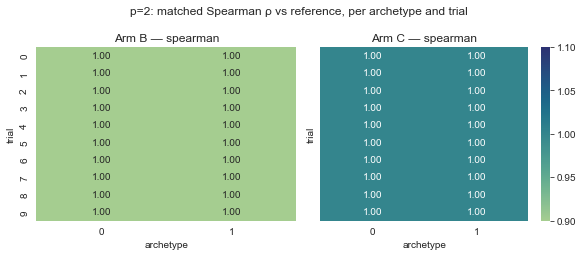

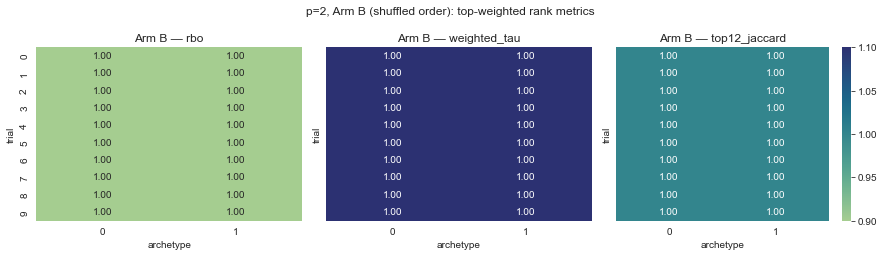

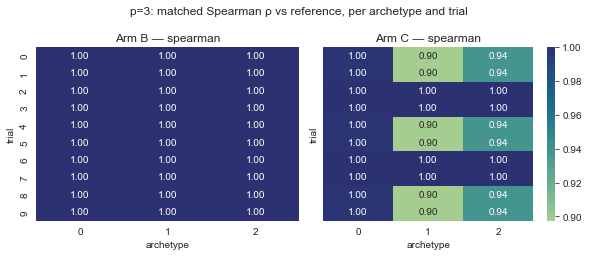

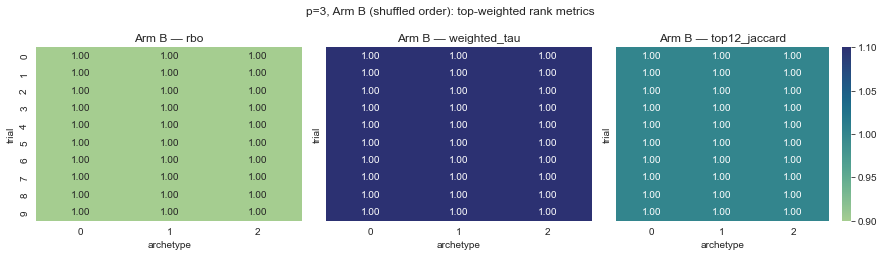

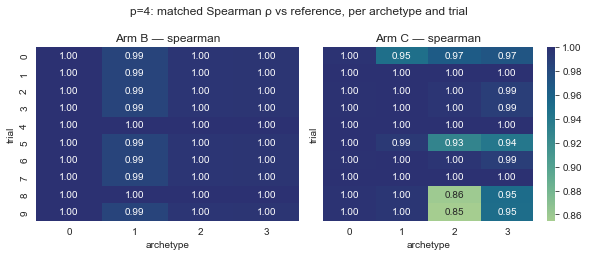

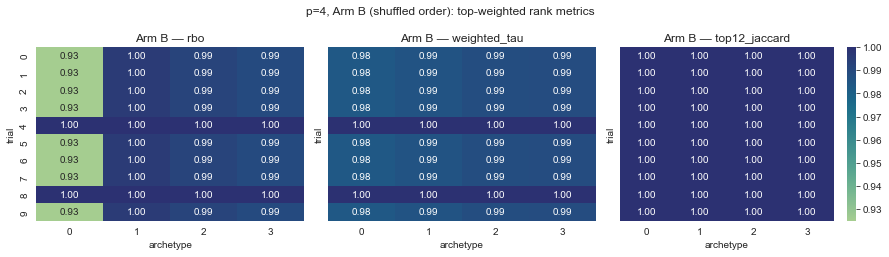

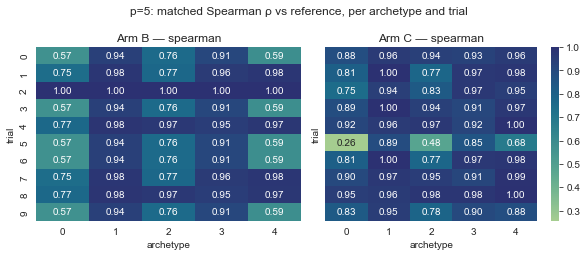

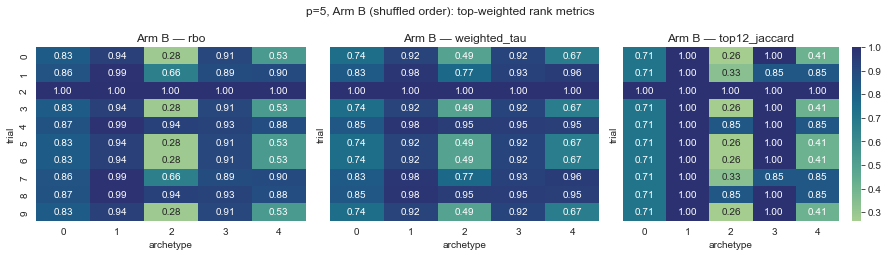

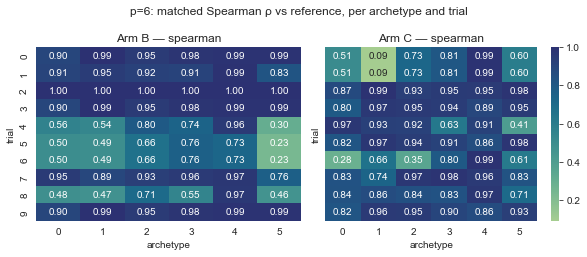

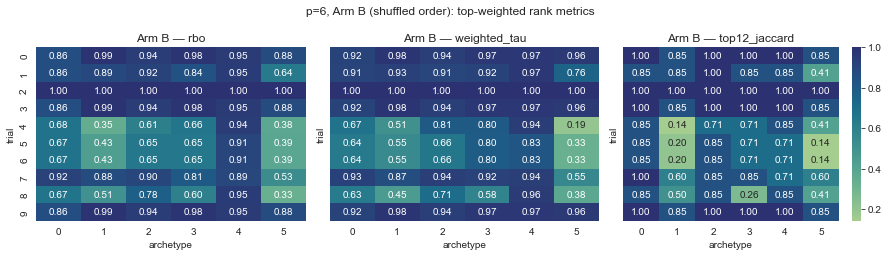

In [9]:
def heatmap_grid(p_run, arm_metric_pairs, suptitle):
    """Row of trial x archetype heatmaps of matched similarity.

    Parameters
    ----------
    p_run : int
        Which experiment (archetype count) to read from `matches`.
    arm_metric_pairs : list of (str, str)
        One heatmap per (arm, metric) pair, e.g. ``[('B', 'rbo'), ...]``.
        All panels share the colour scale (min over panels .. 1.0).
    suptitle : str
        Figure title.
    """
    n = len(arm_metric_pairs)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 3.6), sharey=True)
    axes = np.atleast_1d(axes)
    pivs = [matches[p_run, arm, m][0].pivot(index='trial', columns='archetype', values='sim')
            for arm, m in arm_metric_pairs]
    vmin = min(piv.values.min() for piv in pivs)
    for ax, piv, (arm, m) in zip(axes, pivs, arm_metric_pairs):
        sns.heatmap(piv, annot=True, fmt='.2f', cmap='crest', vmin=vmin, vmax=1.0,
                    cbar=(ax is axes[-1]), ax=ax)
        ax.set_title(f'Arm {arm} — {m}')
    fig.suptitle(suptitle)
    fig.tight_layout()


for p_run in PS:
    heatmap_grid(p_run, [('B', 'spearman'), ('C', 'spearman')],
                 f'p={p_run}: matched Spearman ρ vs reference, per archetype and trial')
    heatmap_grid(p_run, [('B', 'rbo'), ('B', 'weighted_tau'), ('B', 'top12_jaccard')],
                 f'p={p_run}, Arm B (shuffled order): top-weighted rank metrics')

## Arm comparison across p

The headline view: matched similarity to the reference, pooled over archetypes × trials,
for each arm at each `p`. Arm A is the determinism floor (exactly 1 by construction),
Arm B the order-sensitivity question, Arm C the seed-sensitivity yardstick. Three
renderings of the same data:

- **boxplots** and **mean lines (min–max band)** on the linear similarity scale — the
  headline comparison;
- **violins** on a log *dissimilarity* scale (`1 − sim`, exact matches clipped to 1e-16) —
  truer to the distributions, which are bimodal and quantized: trials either reproduce the
  reference (floor) or land on a discrete alternative solution (~1e-1), with almost
  nothing in between. A linear box flattens that into the top gridline; a log box reads
  as uniform spread.

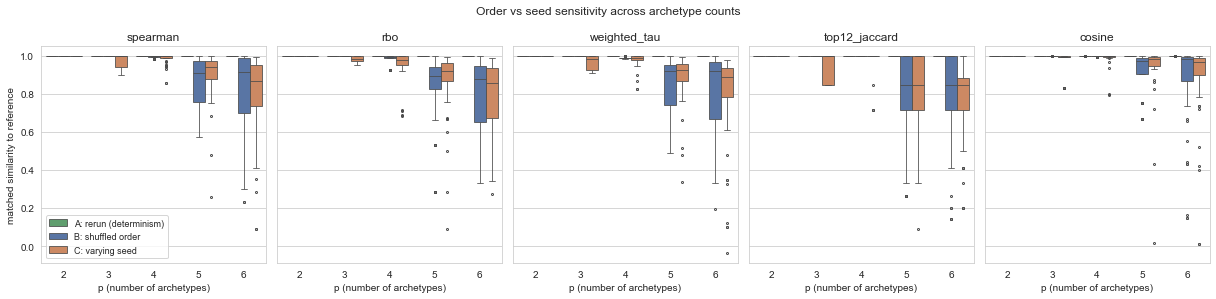

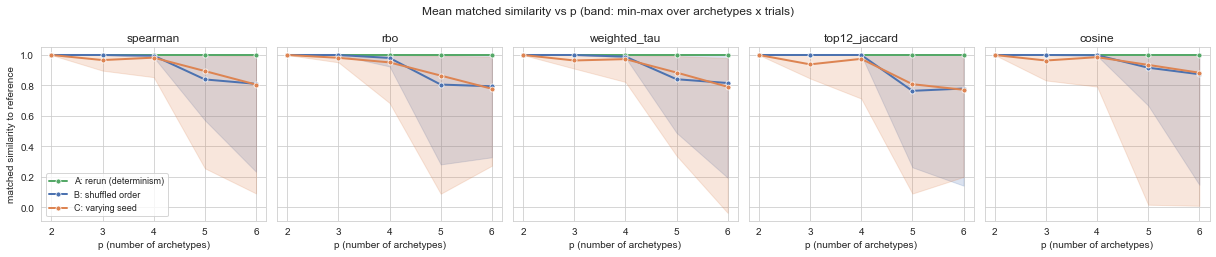

In [10]:
# Matched similarity vs reference, pooled over archetypes x trials, per arm and p
sim_long = pd.concat({key: m for key, (m, _) in matches.items()},
                     names=['p', 'arm', 'metric']).reset_index(['p', 'arm', 'metric'])

ARM_LABELS = {'A': 'A: rerun (determinism)', 'B': 'B: shuffled order', 'C': 'C: varying seed'}
ARM_COLORS = {'A: rerun (determinism)': '#55A868',
              'B: shuffled order': '#4C72B0',
              'C: varying seed': '#DD8452'}
sim_long['arm'] = sim_long['arm'].map(ARM_LABELS)

# Dissimilarity for the log-scale violin view below: 1 - sim, with exact matches
# (1 - sim = 0) clipped to 1e-16 to render on a log axis (same convention as the
# abundance ECDF further down).
FLOOR = 1e-16
sim_long['dissim'] = np.maximum(1.0 - sim_long['sim'], FLOOR)

# Boxplots: one panel per metric, p on the x-axis, one box per arm
fig, axes = plt.subplots(1, len(METRICS), figsize=(3.4 * len(METRICS), 4.2), sharey=True)
for ax, metric in zip(axes, METRICS):
    d = sim_long[sim_long['metric'] == metric]
    sns.boxplot(data=d, x='p', y='sim', hue='arm', hue_order=list(ARM_LABELS.values()),
                palette=ARM_COLORS, linewidth=0.8, fliersize=2,
                legend=(metric == METRICS[0]), ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('p (number of archetypes)')
    ax.set_ylabel('matched similarity to reference' if metric == METRICS[0] else '')
sns.move_legend(axes[0], 'lower left', title=None, frameon=True, fontsize=9)
fig.suptitle('Order vs seed sensitivity across archetype counts')
fig.tight_layout()

# Mean lines with the full min-max range as the band
fig, axes = plt.subplots(1, len(METRICS), figsize=(3.4 * len(METRICS), 3.6), sharey=True)
for ax, metric in zip(axes, METRICS):
    d = sim_long[sim_long['metric'] == metric]
    sns.lineplot(data=d, x='p', y='sim', hue='arm', hue_order=list(ARM_LABELS.values()),
                 palette=ARM_COLORS, estimator='mean', errorbar=('pi', 100),
                 marker='o', markersize=5, lw=2, legend=(metric == METRICS[0]), ax=ax)
    ax.set_xticks(PS)
    ax.set_title(metric)
    ax.set_xlabel('p (number of archetypes)')
    ax.set_ylabel('matched similarity to reference' if metric == METRICS[0] else '')
sns.move_legend(axes[0], 'lower left', title=None, frameon=True, fontsize=9)
fig.suptitle('Mean matched similarity vs p (band: min-max over archetypes x trials)')
fig.tight_layout()

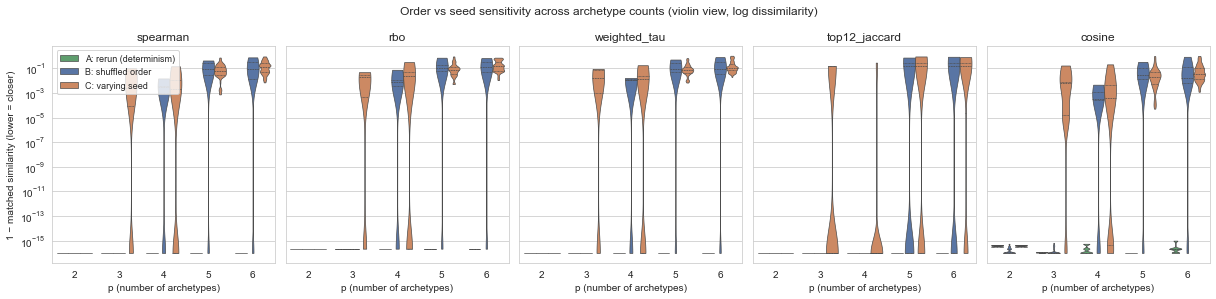

In [11]:
# Violin view: the boxplots mislead for quantized, bimodal metrics (top-12 Jaccard
# takes a handful of discrete values, and trials are either exact or clearly
# different), where a box spanning the floor-to-1e-1 range reads as uniform spread.
# Violins show where the mass actually sits. KDE is computed in log space
# (log_scale=True); cut=0 keeps each violin inside its data range, and the
# zero-variance groups (Arm A, and Arm B at low p) render as flat lines at the floor.
fig, axes = plt.subplots(1, len(METRICS), figsize=(3.4 * len(METRICS), 4.2), sharey=True)
for ax, metric in zip(axes, METRICS):
    d = sim_long[sim_long['metric'] == metric]
    sns.violinplot(data=d, x='p', y='dissim', hue='arm', hue_order=list(ARM_LABELS.values()),
                   palette=ARM_COLORS, log_scale=True, cut=0, density_norm='width',
                   bw_adjust=0.5, inner='quart', linewidth=0.7,
                   legend=(metric == METRICS[0]), ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('p (number of archetypes)')
    ax.set_ylabel('1 − matched similarity (lower = closer)' if metric == METRICS[0] else '')
sns.move_legend(axes[0], 'upper left', title=None, frameon=True, fontsize=9)
fig.suptitle('Order vs seed sensitivity across archetype counts (violin view, log dissimilarity)')
fig.tight_layout()

In [12]:
# Worst-case loading change per trial, after (spearman-)matching
for p_run in PS:
    print(f'p={p_run}  (scale: 99th pct of |reference loadings| = '
          f'{np.percentile(np.abs(exp[p_run]["ref"]["endm"]), 99):.4f})')
    for arm in ARMS:
        perms = matches[p_run, arm, 'spearman'][1]
        dev = np.array([np.abs(res['endm'][:, perm] - exp[p_run]['ref']['endm']).max()
                        for res, perm in zip(exp[p_run][arm], perms)])
        print(f'  Arm {arm}: max |Δ loading| per trial =', np.round(dev, 4))

p=2  (scale: 99th pct of |reference loadings| = 1.0799)
  Arm A: max |Δ loading| per trial = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  Arm B: max |Δ loading| per trial = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  Arm C: max |Δ loading| per trial = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
p=3  (scale: 99th pct of |reference loadings| = 1.5111)
  Arm A: max |Δ loading| per trial = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  Arm B: max |Δ loading| per trial = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  Arm C: max |Δ loading| per trial = [0.4509 0.4509 0.011  0.011  0.4509 0.4509 0.011  0.     0.4509 0.4509]
p=4  (scale: 99th pct of |reference loadings| = 1.5242)
  Arm A: max |Δ loading| per trial = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  Arm B: max |Δ loading| per trial = [0.0958 0.0958 0.0958 0.0958 0.     0.0958 0.0958 0.0958 0.     0.0958]
  Arm C: max |Δ loading| per trial = [0.6701 0.     0.1027 0.1027 0.     0.4308 0.1027 0.     0.827  0.8367]
p=5  (scale: 99th pct of |reference loadings| = 1.7233)
  Arm A: max |Δ loading| per trial 

## Abundance consistency

Trial abundances are already back in reference precinct order (Arm B was un-shuffled at
collection time); applying the matched archetype permutation (spearman-Hungarian) makes
them directly comparable row-for-row with the reference. Two views:

- per-archetype Pearson r across all precincts — "does the map look the same?"
- per-precinct max |Δ abundance| — "how far does any single precinct move?"

In [13]:
def abundance_consistency(p_run, arm):
    """Per-archetype correlation of each trial's aligned abundances vs the reference.

    Parameters
    ----------
    p_run : int
        Which experiment (archetype count) to read from `exp` / `matches`.
    arm : {'A', 'B', 'C'}
        Which arm's trials to evaluate. Archetypes are aligned with the
        spearman-Hungarian permutations.

    Returns
    -------
    table : pandas.DataFrame
        One row per (trial, archetype) with the Pearson r between the
        trial's and the reference's abundance vectors across all precincts.
    """
    ref_ab = exp[p_run]['ref']['abundances']
    perms = matches[p_run, arm, 'spearman'][1]
    rows = []
    for t, (res, perm) in enumerate(zip(exp[p_run][arm], perms)):
        A = res['abundances'][perm, :]           # archetype rows into reference order
        for k in range(A.shape[0]):
            rows.append({'trial': t, 'archetype': k,
                         'pearson_r': pearsonr(A[k], ref_ab[k])[0]})
    return pd.DataFrame(rows)


ab = pd.concat({(p_run, arm): abundance_consistency(p_run, arm)
                for p_run in PS for arm in ARMS}, names=['p', 'arm'])
ab.groupby(['p', 'arm', 'archetype'])['pearson_r'].agg(['mean', 'min']).unstack('arm').round(3)

mean                min              
arm            A      B      C    A      B      C
p archetype                                      
2 0          1.0  1.000  1.000  1.0  1.000  1.000
  1          1.0  1.000  1.000  1.0  1.000  1.000
3 0          1.0  1.000  1.000  1.0  1.000  1.000
  1          1.0  1.000  0.998  1.0  1.000  0.996
  2          1.0  1.000  0.989  1.0  1.000  0.982
4 0          1.0  0.997  0.981  1.0  0.996  0.931
  1          1.0  1.000  0.997  1.0  1.000  0.990
  2          1.0  1.000  0.997  1.0  1.000  0.975
  3          1.0  1.000  0.999  1.0  1.000  0.993
5 0          1.0  0.685  0.878  1.0  0.406  0.394
  1          1.0  0.971  0.991  1.0  0.952  0.963
  2          1.0  0.992  0.950  1.0  0.984  0.798
  3          1.0  0.982  0.996  1.0  0.964  0.968
  4          1.0  0.847  0.945  1.0  0.693  0.626
6 0          1.0  0.926  0.830  1.0  0.850  0.142
  1          1.0  0.675  0.757  1.0  0.209  0.426
  2          1.0  0.739  0.920  1.0  0.300  0.726
  3          1.0  0.967  0.929  1.0  0.824  0.413
  4          1.0  0.994  0.998  1.0  0.976  0.980
  5          1.0  0.486  0.972  1.0 -0.343  0.936

p=2 arm B: median=1.94e-16, 99th pct=9.44e-16, max=2.33e-15
p=2 arm C: median=0.00e+00, 99th pct=0.00e+00, max=0.00e+00
p=3 arm B: median=5.55e-16, 99th pct=1.89e-15, max=2.75e-15
p=3 arm C: median=9.17e-02, 99th pct=2.08e-01, max=2.67e-01
p=4 arm B: median=6.56e-03, 99th pct=1.94e-02, max=3.20e-02
p=4 arm C: median=4.93e-03, 99th pct=2.06e-01, max=2.83e-01
p=5 arm B: median=8.30e-02, 99th pct=1.58e-01, max=3.14e-01
p=5 arm C: median=3.79e-02, 99th pct=1.75e-01, max=3.20e-01
p=6 arm B: median=5.68e-02, 99th pct=2.50e-01, max=5.44e-01
p=6 arm C: median=5.85e-02, 99th pct=1.35e-01, max=4.17e-01


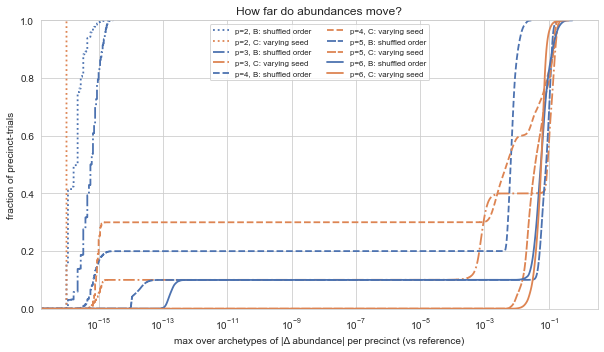

In [14]:
def per_precinct_maxdiff(p_run, arm):
    """Worst abundance shift per precinct, pooled over one arm's trials.

    Parameters
    ----------
    p_run : int
        Which experiment (archetype count) to read from `exp` / `matches`.
    arm : {'A', 'B', 'C'}
        Which arm's trials to evaluate. Archetypes are aligned with the
        spearman-Hungarian permutations.

    Returns
    -------
    diffs : ndarray, shape (n_trials * N,)
        For every (trial, precinct): the max over archetypes of
        |Δ abundance| vs the reference.
    """
    ref_ab = exp[p_run]['ref']['abundances']
    perms = matches[p_run, arm, 'spearman'][1]
    return np.concatenate([
        np.abs(res['abundances'][perm, :] - ref_ab).max(axis=0)
        for res, perm in zip(exp[p_run][arm], perms)])


# Arm A is identically zero (determinism check above), so only B and C are drawn
fig, ax = plt.subplots(figsize=(8.5, 5))
colors = {'B': '#4C72B0', 'C': '#DD8452'}                       # color = arm
styles = dict(zip(PS, [':', '-.', '--', (0, (5, 1)), '-']))    # linestyle = p
for p_run in PS:
    for arm in ['B', 'C']:
        d = per_precinct_maxdiff(p_run, arm)
        # clip at 1e-16 so bitwise-identical trials (diff = 0) still render on the log axis
        sns.ecdfplot(x=np.maximum(d, 1e-16), ax=ax, color=colors[arm], ls=styles[p_run],
                     lw=1.8, label=f'p={p_run}, {"B: shuffled order" if arm == "B" else "C: varying seed"}')
        print(f'p={p_run} arm {arm}: median={np.median(d):.2e}, '
              f'99th pct={np.percentile(d, 99):.2e}, max={d.max():.2e}')
ax.set_xscale('log')
ax.set_xlabel('max over archetypes of |Δ abundance| per precinct (vs reference)')
ax.set_ylabel('fraction of precinct-trials')
ax.set_title('How far do abundances move?')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()

## Conclusions

**The instability switches on between `p = 4` and `p = 5` — sharply, not gradually.**
Below the threshold, solutions are reproducible essentially down to the bit under precinct
reordering; above it, both reordering and reseeding hop between discrete alternative
solutions. The instability is degeneracy of the decomposition, not an ordering artifact
per se — at `p ≥ 5` order sensitivity ≈ seed sensitivity (mean matched Spearman, B vs C:
0.84 vs 0.90 at `p = 5`, 0.81 vs 0.81 at `p = 6`), two symptoms of the same
near-degenerate optimum.

**Regime by regime** (sweep: 31 runs per `p`; Arm A bitwise-identical to the reference at
every `p`, so the baseline is deterministic throughout):
- **`p = 2`: stable against everything.** Even varying the seed reproduces the reference
  bitwise in all 10 trials.
- **`p = 3`: order-exact, seed wobbles.** Shuffles are still bitwise-identical; Arm C hops
  between the reference and one nearby alternative (max |Δ loading| 0.45 on a ~1.5 scale,
  min top-12 Jaccard 0.846).
- **`p = 4`: order sensitivity negligible.** Every shuffle lands on the reference or a
  hair away (max |Δ loading| ≈ 0.10): top-12 Jaccard is 1.000 for every archetype in
  every trial — the same 12-candidate slates, always — min matched Spearman 0.985, and
  abundance maps essentially exact (min Pearson r ≥ 0.996). Seed sensitivity grows but
  stays moderate (Arm C min Spearman 0.855, min top-12 Jaccard 0.714).
- **`p = 5`: the degeneracy arrives.** Arm B drops to mean Spearman 0.840 (min 0.572,
  min RBO 0.282) with |Δ loading| up to 1.52 — on par with Arm C (min Spearman 0.257, min
  RBO 0.090). Archetype 0's abundance map is the casualty (Arm B mean r 0.685, min 0.41).
- **`p = 6`: both arms ~0.81 mean Spearman** with catastrophic worst cases: min top-12
  Jaccard 0.143 — the "same" archetype electing a mostly different slate. Abundance maps
  are more robust than loadings except the unstable archetypes (worst: archetype 5 under
  shuffling, mean r 0.486, min −0.34; archetype 0 under reseeding, min r 0.142).

**Structure of the instability (violin view):**
- The distributions are **bimodal and quantized**: trials either reproduce the reference
  (dissimilarity at the float floor) or land on a discrete alternative solution
  (dissimilarity ~1e-1), with almost nothing in between. The pipeline hops between a
  handful of discrete optima rather than diffusing around one.
- All of them fit identically — the RMSE range over the 31 runs is ≤ 1e-6 at every `p` —
  so the data does not single out one solution once the degeneracy sets in.
- *Caveat on per-trial outcomes:* **which** shuffle lands on which solution is not stable
  across separate executions of the identical code and seeds (the earlier two-point run
  had 8/10 bitwise reproductions at `p = 4`; this sweep, 2/10 — the rest differing by the
  same |Δ loading| ≈ 0.10) — float-level sensitivity, plausibly BLAS threading. The
  solution set and all summary statistics reproduce; per-trial labels do not. Conclusions
  here lean only on the former.
- Matching ambiguity follows the same boundary: every metric and the greedy matcher agree
  100% on the archetype correspondence through `p = 4`; disagreements appear at `p = 5`
  (80–100%) and widen at `p = 6` (80–95%).

**On the metrics (RBO / weighted τ / top-12 Jaccard vs Spearman):**
- The choice of metric does not change the matching story — only how harshly disagreement
  is scored.
- The top-weighted metrics expose what Spearman smooths over: at `p = 6` the worst
  matched pairs score Spearman ≈ 0.23 (B) / 0.09 (C) but **top-12 Jaccard ≈ 0.14** —
  Spearman's higher values are propped up by agreement in the long tail of no-hope
  candidates (weighted τ even goes negative, −0.04, for one Arm C pair). For headline
  claims ("archetype X's slate"), top-12 Jaccard is the most honest reporting metric;
  RBO is the best single top-weighted summary.

**The price of stability:** RMSE falls monotonically with `p` (0.0578 → 0.0475 → 0.0386 →
0.0357 → 0.0337 for `p` = 2…6), so dropping from 6 to 4 costs ~15% in fit — but buys
solutions that are actually reproducible.

**Practical upshot:** run the production analysis at **`p = 4`** — the largest `p` that is
*both* mutually distinct (notebook 08's criterion) *and* reproducible under reordering
with unambiguous matching; the sweep shows these two thresholds coincide. `p = 2–3` are
even more stable but coarser. Anything at `p ≥ 5` needs consensus/ensemble treatment and
top-weighted (not Spearman) similarity reporting.